In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

In [2]:
wind_speed = pd.read_csv('https://tubcloud.tu-berlin.de/s/X8WGZxA6554iSz9/download/wind-speeds.csv', index_col=0, parse_dates=True)
wind_speed.head()

,wind_speed_m_s
time,
2019-01-01 00:00:00,11.484892
2019-01-01 01:00:00,11.835971
2019-01-01 02:00:00,12.323022
2019-01-01 03:00:00,13.186331
2019-01-01 04:00:00,14.068345


### Converting $10m$ wind speed data into $90m$ using log law

In [3]:
z_r = 10   # reference height in meters
z   = 90   # hub height in meters
z0  = 0.03 # terrain roughness

# scaling factor
scale = (np.log(z/z0)/np.log(z_r/z0))

wind_speed['wind_speed_m_s_at_90m'] = wind_speed['wind_speed_m_s'] * scale
print(f'Scaling Factor: {scale}')
wind_speed.head()

Scaling Factor: 1.3782355815650944


,wind_speed_m_s,wind_speed_m_s_at_90m
time,,
2019-01-01 00:00:00,11.484892,15.828887
2019-01-01 01:00:00,11.835971,16.312757
2019-01-01 02:00:00,12.323022,16.984027
2019-01-01 03:00:00,13.186331,18.173870
2019-01-01 04:00:00,14.068345,19.389494


### Applying power curve to wind speed data

In [4]:
def vestas_power_curve(w): # 3 MW nominal
    conditions = [
        w < 4,
        (w >= 4) & (w < 6),
        (w >= 6) & (w < 8),
        (w >= 8) & (w < 10),
        (w >= 10) & (w < 12),
        (w >= 12) & (w <= 22),
        w > 22
    ]

    choices = [0, 0.2, 0.5, 1.3, 2.5, 3, 0]

    return np.select(conditions, choices)

def enercon_power_curve(w): # 3 MW nominal
    conditions = [
        w < 4,
        (w >= 4) & (w < 6),
        (w >= 6) & (w < 8),
        (w >= 8) & (w < 10),
        (w >= 10) & (w < 12),
        (w >= 12) & (w <= 14),
        (w >= 14) & (w <= 16),
        (w >= 16) & (w <= 25),
        w > 25
    ]

    choices = [0, 0.4, 0.8, 1.5, 2.1, 2.4, 2.9, 3, 0]

    return np.select(conditions, choices)

wind_speed["vestas_power_MW"] = vestas_power_curve(wind_speed["wind_speed_m_s_at_90m"])
wind_speed["enercon_power_MW"] = enercon_power_curve(wind_speed["wind_speed_m_s_at_90m"])
wind_speed.head()

,wind_speed_m_s,wind_speed_m_s_at_90m,vestas_power_MW,enercon_power_MW
time,,,,
2019-01-01 00:00:00,11.484892,15.828887,3.0,2.9
2019-01-01 01:00:00,11.835971,16.312757,3.0,3.0
2019-01-01 02:00:00,12.323022,16.984027,3.0,3.0
2019-01-01 03:00:00,13.186331,18.173870,3.0,3.0
2019-01-01 04:00:00,14.068345,19.389494,3.0,3.0


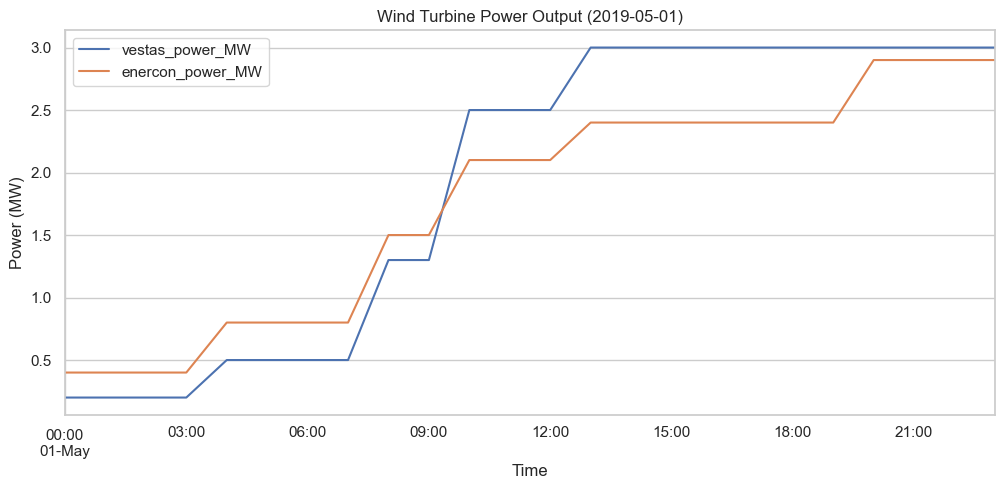

In [5]:
wind_may1 = wind_speed.loc["2019-05-01"]
#wind_week = wind_speed.loc["2019-05-01":"2019-05-07"]
wind_may1[["vestas_power_MW", "enercon_power_MW"]].plot(figsize=(12,5))
plt.title("Wind Turbine Power Output (2019-05-01)")
plt.ylabel("Power (MW)")
plt.xlabel("Time")
plt.grid(True)
plt.show()

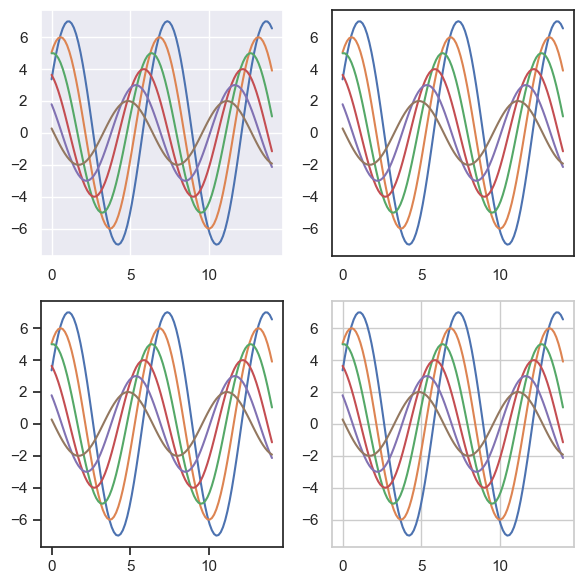

In [6]:
def sinplot(n=10, flip=1):
    x = np.linspace(0, 14, 100)
    for i in range(1, n + 1):
        plt.plot(x, np.sin(x + i * .5) * (n + 2 - i) * flip)
f = plt.figure(figsize=(6, 6))
gs = f.add_gridspec(2, 2)

with sns.axes_style("darkgrid"):
    ax = f.add_subplot(gs[0, 0])
    sinplot(6)

with sns.axes_style("white"):
    ax = f.add_subplot(gs[0, 1])
    sinplot(6)

with sns.axes_style("ticks"):
    ax = f.add_subplot(gs[1, 0])
    sinplot(6)

with sns.axes_style("whitegrid"):
    ax = f.add_subplot(gs[1, 1])
    sinplot(6)

f.tight_layout()

### Energy in relative margin %

In [7]:
vestas_energy = wind_speed["vestas_power_MW"].sum()
enercon_energy = wind_speed["enercon_power_MW"].sum()

if vestas_energy > enercon_energy:
    print("Vestas produces more energy")
else:
    print("Enercon produces more energy")

percent_diff = abs(vestas_energy - enercon_energy) / ((vestas_energy + enercon_energy) / 2) * 100
print(f'Relative Margin in %: {percent_diff:.2f}')

Vestas produces more energy
Relative Margin in %: 0.98


In [8]:
# Normalized power rating
wind_speed["vestas_cf_pu"] = wind_speed["vestas_power_MW"] / 3
wind_speed["enercon_cf_pu"] = wind_speed["enercon_power_MW"] / 3

vestas_cf = wind_speed["vestas_cf_pu"].mean()
enercon_cf = wind_speed["enercon_cf_pu"].mean()

print(f"Vestas Annual Average Capacity Factor:  {vestas_cf:.4f} p.u.")
print(f"Enercon Annual Average Capacity Factor: {enercon_cf:.4f} p.u.")

Vestas Annual Average Capacity Factor:  0.5096 p.u.
Enercon Annual Average Capacity Factor: 0.5046 p.u.


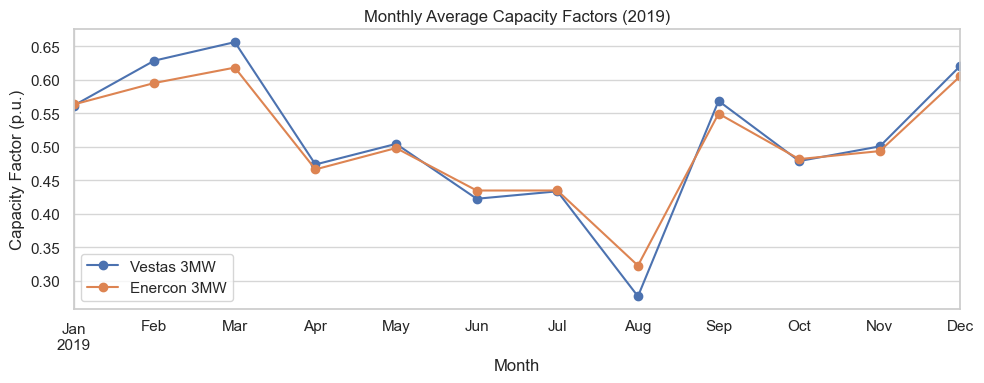

In [9]:
# Monthy average capacity factor
monthly_cf = wind_speed[["vestas_cf_pu", "enercon_cf_pu"]].resample("ME").mean()

fig, ax = plt.subplots(figsize=(10, 4))

monthly_cf["vestas_cf_pu"].plot(ax=ax, marker="o", label="Vestas 3MW")
monthly_cf["enercon_cf_pu"].plot(ax=ax, marker="o", label="Enercon 3MW")

ax.set_xlabel("Month")
ax.set_ylabel("Capacity Factor (p.u.)")
ax.set_title("Monthly Average Capacity Factors (2019)")
ax.legend()
ax.grid(True, alpha=0.8)

plt.tight_layout()
plt.show()

In [10]:
vestas_zero_share = (wind_speed["vestas_cf_pu"] == 0).sum() / len(wind_speed) * 100
enercon_zero_share = (wind_speed["enercon_cf_pu"] == 0).sum() / len(wind_speed) * 100
print(f"Share of time Vestas produces no power: {vestas_zero_share:.2f}%")
print(f"Share of time Enercon produces no power: {enercon_zero_share:.2f}%")

Share of time Vestas produces no power: 4.04%
Share of time Enercon produces no power: 4.04%


In [11]:
vestas_rated_share = (wind_speed["vestas_cf_pu"] == 1).sum() / len(wind_speed) * 100
enercon_rated_share = (wind_speed["enercon_cf_pu"] == 1).sum() / len(wind_speed) * 100
print(f"Share of time Vestas produces at rated capacity: {vestas_rated_share:.2f}%")
print(f"Share of time Enercon produces at rated capacity: {enercon_rated_share:.2f}%")

Share of time Vestas produces at rated capacity: 18.90%
Share of time Enercon produces at rated capacity: 2.89%


In [12]:
vestas_shutdown = (wind_speed["wind_speed_m_s_at_90m"] > 22).any()
enercon_shutdown = (wind_speed["wind_speed_m_s_at_90m"] > 25).any()
print(f"Does Vestas ever shut down due to high winds? {vestas_shutdown}")
print(f"Does Enercon ever shut down due to high winds? {enercon_shutdown}")

Does Vestas ever shut down due to high winds? False
Does Enercon ever shut down due to high winds? False


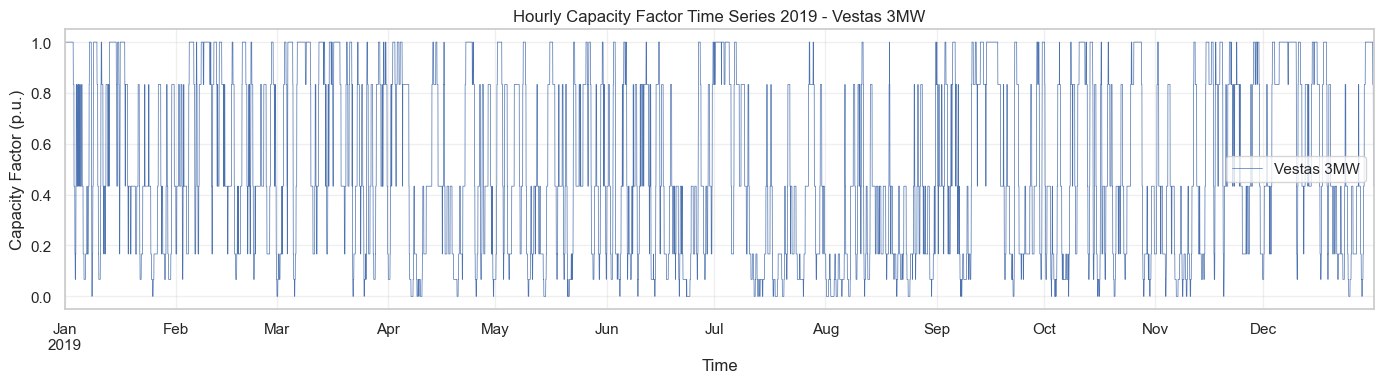

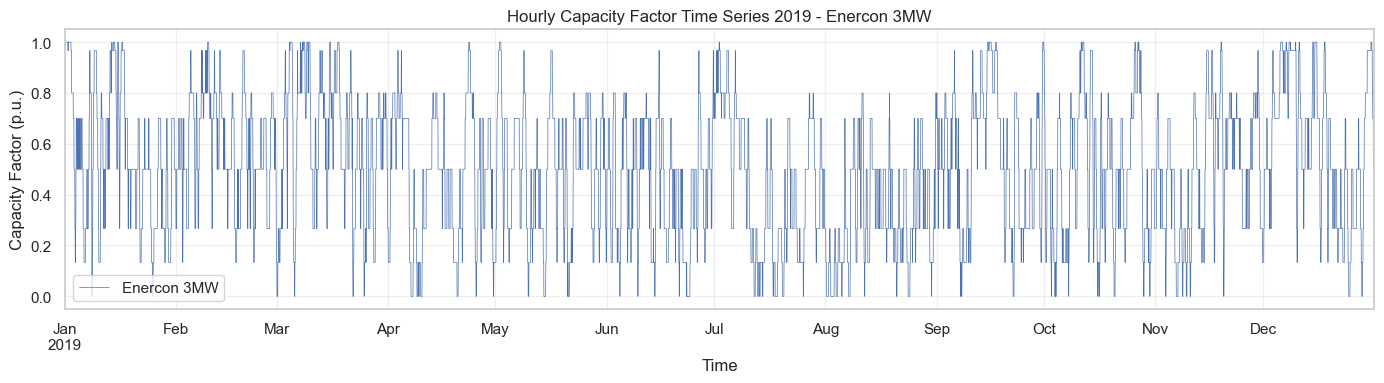

In [13]:
# Capacity factor time series
fig, ax = plt.subplots(figsize=(14, 4))

wind_speed["vestas_cf_pu"].plot(ax=ax, label="Vestas 3MW", linewidth=0.5)

ax.set_xlabel("Time")
ax.set_ylabel("Capacity Factor (p.u.)")
ax.set_title("Hourly Capacity Factor Time Series 2019 - Vestas 3MW")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))

wind_speed["enercon_cf_pu"].plot(ax=ax, label="Enercon 3MW", linewidth=0.5)

ax.set_xlabel("Time")
ax.set_ylabel("Capacity Factor (p.u.)")
ax.set_title("Hourly Capacity Factor Time Series 2019 - Enercon 3MW")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
wind_speed.to_csv('../data/wind_speed.csv', index=False)